In [1]:
# Configura matplotlib para mostrar las gráficas directamente en el notebook (modo inline)
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline


Guía para el uso correcto de `non_blocking` y `pin_memory()` en PyTorch
========================================================================

**Autor**: [Vincent Moens](https://github.com/vmoens)

Introducción
------------

La transferencia de datos de CPU a GPU es fundamental en muchas aplicaciones
PyTorch. Es crucial que los usuarios comprendan las herramientas y opciones
más eficaces para mover datos entre dispositivos. Este tutorial examina dos
métodos clave para la transferencia de datos entre dispositivos en PyTorch:
`~torch.Tensor.pin_memory`{.interpreted-text role="meth"} y
`~torch.Tensor.to`{.interpreted-text role="meth"} con la opción
`non_blocking=True`.

### Qué aprenderás

La optimización de la transferencia de tensores de CPU a GPU puede lograrse
mediante transferencias asíncronas y fijado de memoria. Sin embargo, hay
consideraciones importantes:

-   Usar `tensor.pin_memory().to(device, non_blocking=True)` puede ser hasta
    dos veces más lento que un simple `tensor.to(device)`.
-   En general, `tensor.to(device, non_blocking=True)` es una buena opción
    para mejorar la velocidad de transferencia.
-   Mientras que `cpu_tensor.to("cuda", non_blocking=True).mean()` se ejecuta
    correctamente, intentar
    `cuda_tensor.to("cpu", non_blocking=True).mean()` producirá resultados
    incorrectos.

### Preámbulo

Los resultados de rendimiento reportados en este tutorial dependen del sistema
utilizado para construirlo. Aunque las conclusiones son aplicables en distintos
sistemas, las observaciones específicas pueden variar ligeramente según el
hardware disponible, especialmente en hardware más antiguo. El objetivo
principal de este tutorial es ofrecer un marco teórico para entender las
transferencias de datos de CPU a GPU. Sin embargo, cualquier decisión de diseño
debe adaptarse a cada caso concreto y guiarse por mediciones de rendimiento
específicas, así como por los requisitos particulares de la tarea en cuestión.


In [2]:
# Importa la librería principal de PyTorch
import torch

# Verifica que haya una GPU con CUDA disponible; sin GPU este tutorial no puede ejecutarse
if torch.cuda.is_available():
    print(f"CUDA disponible: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA NO disponible. Este tutorial requiere una GPU.")
    raise RuntimeError("A cuda device is required to run this tutorial")

CUDA disponible: NVIDIA RTX 5000 Ada Generation


Este tutorial requiere que tensordict esté instalado. Si aún no lo tienes en
tu entorno, instálalo ejecutando el siguiente comando en una celda aparte:

``` {.bash}
# Instala tensordict con el siguiente comando
pip install tensordict
```

Comenzamos describiendo la teoría de estos conceptos y luego pasamos a
ejemplos concretos de las funcionalidades.

Fundamentos
===========

Conceptos básicos de gestión de memoria
----------------------------------------

Cuando se crea un tensor CPU en PyTorch, su contenido debe almacenarse en
memoria. La memoria de la que hablamos es un concepto bastante complejo que
merece estudiarse con cuidado. Distinguimos dos tipos de memoria gestionados
por la Unidad de Gestión de Memoria (MMU): la RAM (simplificando) y el
espacio de intercambio en disco (swap), que puede o no ser el disco duro.
Juntos, el espacio disponible en disco y en RAM (memoria física) conforman la
memoria virtual, que es una abstracción del total de recursos disponibles. En
resumen, la memoria virtual hace que el espacio disponible sea mayor que el de
la RAM en solitario, creando la ilusión de que la memoria principal es más
grande de lo que realmente es.

En circunstancias normales, un tensor CPU ordinario es paginable, lo que
significa que está dividido en bloques llamados páginas que pueden residir en
cualquier parte de la memoria virtual (tanto en RAM como en disco). Como se
mencionó antes, esto tiene la ventaja de que la memoria parece mayor de lo que
realmente es la memoria principal.

Típicamente, cuando un programa accede a una página que no está en RAM, se
produce un «fallo de página» y el sistema operativo (SO) recupera esa página
en RAM («swap in» o «page in»). A su vez, el SO puede tener que desalojar
(«swap out» o «page out») otra página para hacer espacio a la nueva.

A diferencia de la memoria paginable, la memoria fijada (o page-locked o
no paginable) es un tipo de memoria que no puede intercambiarse al disco.
Permite tiempos de acceso más rápidos y predecibles, pero tiene la desventaja
de que es más limitada que la memoria paginable (la memoria principal).

![](https://pytorch.org/tutorials/_static/img/pinmem/pinmem.png)

CUDA y la memoria (no) paginable
----------------------------------

Para entender cómo CUDA copia un tensor de CPU a CUDA, consideremos los dos
escenarios anteriores:

-   Si la memoria es page-locked, el dispositivo puede acceder directamente a
    ella en la memoria principal. Las direcciones de memoria están bien
    definidas y las funciones que necesitan leer esos datos pueden acelerarse
    significativamente.
-   Si la memoria es paginable, todas las páginas deben traerse a la memoria
    principal antes de enviarse a la GPU. Esta operación puede llevar tiempo y
    es menos predecible que cuando se ejecuta sobre tensores de memoria fijada.

Más concretamente, cuando CUDA envía datos paginables de CPU a GPU, primero
debe crear una copia page-locked de esos datos antes de realizar la transferencia.

Operaciones asíncronas vs. síncronas con `non_blocking=True` (CUDA `cudaMemcpyAsync`)
---------------------------------------------------------------------------------------

Al ejecutar una copia desde un host (como la CPU) hacia un dispositivo (como
la GPU), el toolkit de CUDA ofrece modalidades para realizar estas operaciones
de forma síncrona o asíncrona con respecto al host.

En la práctica, al llamar a `~torch.Tensor.to`{.interpreted-text role="meth"},
PyTorch siempre realiza una llamada a
[cudaMemcpyAsync](https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__MEMORY.html#group__CUDART__MEMORY_1g85073372f776b4c4d5f89f7124b7bf79).
Si `non_blocking=False` (por defecto), se llamará a `cudaStreamSynchronize`
después de cada `cudaMemcpyAsync`, haciendo que la llamada a
`~torch.Tensor.to`{.interpreted-text role="meth"} sea bloqueante en el hilo
principal. Si `non_blocking=True`, no se dispara ninguna sincronización y el
hilo principal del host no se bloquea. Por tanto, desde la perspectiva del
host, múltiples tensores pueden enviarse al dispositivo simultáneamente, ya
que el hilo no necesita esperar a que una transferencia complete para iniciar
la siguiente.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTA:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>En general, la transferencia es bloqueante en el lado del dispositivo (aunque no lo sea en el lado del host): la copia en el dispositivo no puede ocurrir mientras se está ejecutando otra operación. Sin embargo, en algunos escenarios avanzados, una copia y una ejecución de kernel pueden realizarse simultáneamente en la GPU. Como demostrará el siguiente ejemplo, deben cumplirse tres requisitos para habilitar esto. Lo demostramos ejecutando perfiles sobre el siguiente script.</p>

</div>


In [ ]:
import contextlib
from torch.cuda import Stream

# Crea un stream CUDA secundario que se usará para copias en paralelo al stream principal
s = Stream()

# Establece una semilla fija para la generación de números aleatorios, lo que garantiza que los resultados sean reproducibles
torch.manual_seed(42)

# Tensor CPU almacenado en memoria fijada (no paginable - pin_memory=True): no puede ser paginado al disco, lo que permite que CUDA acceda a él directamente sin necesidad de hacer una copia previa. MAS RÁPIDO para transferencias a la GPU, pero consume más memoria RAM y no puede ser paginado por el sistema operativo.
t1_cpu_pinned = torch.randn(1024**2 * 5, pin_memory=True)
print(f"Tensor CPU con pin_memory=True, localizado en: {t1_cpu_pinned.device}")
print(f't1_cpu_pinned shape = {t1_cpu_pinned.shape}')
print(f't1_cpu_pinned = {t1_cpu_pinned}\n')

# Tensor CPU almacenado en memoria paginable (paginable - pin_memory=False - por defecto): puede ser movido al disco por el SO; CUDA debe copiarlo primero a memoria fijada antes de enviarlo a la GPU. MAS LENTO para transferencias a la GPU, pero consume menos memoria RAM y puede ser paginado por el sistema operativo.
# Esta linea de código sería equivalente, no es necesario poner pin_memory=False explícitamente, ya que es el valor por defecto:    # t2_cpu_paged = torch.randn(1024**2 * 5)
t2_cpu_non_pinned = torch.randn(1024**2 * 5, pin_memory=False)
print(f"Tensor CPU con pin_memory=False, localizado en: {t2_cpu_non_pinned.device}")
print(f't2_cpu_non_pinned shape = {t2_cpu_non_pinned.shape}')
print(f't2_cpu_non_pinned = {t2_cpu_non_pinned}\n')

# Tensor ya residente en la GPU (device="cuda:0")
t3_cuda = torch.randn(1024**2 * 5, device="cuda:0")
print(f"Tensor GPU, localizado en: {t3_cuda.device}")
print(f't3_cuda shape = {t3_cuda.shape}')
print(f't3_cuda = {t3_cuda}\n')

assert torch.cuda.is_available()
# Obtiene el dispositivo CUDA activo actual
device = torch.device("cuda", torch.cuda.current_device())
print(f"Dispositivo CUDA activo: {device}")

Tensor CPU con pin_memory=True, localizado en: cpu
t1_cpu_pinned shape = torch.Size([5242880])
t1_cpu_pinned = tensor([ 1.9269,  1.4873,  0.9007,  ..., -0.3000, -0.6091,  0.0396])

Tensor CPU con pin_memory=False, localizado en: cpu
t2_cpu_non_pinned shape = torch.Size([5242880])
t2_cpu_non_pinned = tensor([-0.5908, -0.4110,  0.4050,  ..., -0.6500, -1.6040,  0.8014])

Tensor GPU, localizado en: cuda:0
t3_cuda shape = torch.Size([5242880])
t3_cuda = tensor([ 0.1940,  2.1614, -0.1721,  ...,  0.3208, -2.1392,  1.5880],
       device='cuda:0')

Dispositivo CUDA activo: cuda:0


In [ ]:

# =============================================================================
# FUNCIÓN PRINCIPAL DE BENCHMARKING: inner(pinned, streamed)
#
# ─────────────────────────────────────────────────────────────────────────────
#                     ACLARACIÓN SOBRE EL CONCEPTO DE "PARALELISMO"
# ─────────────────────────────────────────────────────────────────────────────
#
# En este notebook aparecen DOS niveles distintos de paralelismo. Confundirlos
# lleva a interpretaciones erróneas, así que conviene distinguirlos claramente:
#
#  NIVEL 1 — Paralelismo en el ENVÍO (CPU → GPU):
#    → Se refiere a si la CPU puede iniciar MÚLTIPLES transferencias de tensores
#      hacia la GPU sin esperar a que cada una termine.
#    → Controlado por non_blocking=True en la llamada .to(device).
#    → Con non_blocking=False (por defecto): la CPU se bloquea tras cada copia
#      (llama internamente a cudaStreamSynchronize y espera a que la GPU confirme que
#      la transferencia ha terminado antes de continuar).
#    → Con non_blocking=True: la CPU lanza la orden de copia a la GPU y regresa
#      de inmediato sin esperar a que la transferencia termine. Puede lanzar la siguiente
#      transferencia al instante → múltiples transferencias activas a la vez en la GPU.
#      Desde la perspectiva de la CPU, los tensores se lanzan "en paralelo" hacia la GPU.
#
#  NIVEL 2 — Paralelismo en la EJECUCIÓN INTERNA de la GPU:
#    → Se refiere a si el motor DMA (copiando datos desde CPU) y los núcleos
#      de cómputo (ejecutando una operación de cómputo) pueden trabajar AL MISMO
#      TIEMPO dentro de la GPU.
#    → La GPU SIEMPRE tiene esta capacidad de hardware; no es algo que se
#      active o desactive: son unidades físicas independientes (DMA engine
#      y Streaming Multiprocessors).
#    → Lo que varía es si se dan las CONDICIONES para aprovecharlo:
#        • El DMA y la operación de cómputo deben estar en streams DISTINTOS de la GPU.
#        • La transferencia debe ser desde memoria FIJADA (pinned), para que
#          el DMA pueda arrancar inmediatamente sin bloquear la CPU.
#        • Si la memoria es PAGINABLE, la CPU se bloquea haciendo el
#          staging (pageable → pinned) y no puede enviar la orden de multiplicación
#          a tiempo → la GPU no recibe el trabajo y sus núcleos quedan ociosos,
#          aunque físicamente serían capaces de ejecutarlo en paralelo.
#
#  CONCLUSIÓN CLAVE:
#    La GPU no "pierde" su capacidad de ejecutar en paralelo con memoria
#    paginable. Lo que ocurre es que la CPU no puede alimentarla con ambas
#    órdenes a tiempo:
#       - La orden de copia (cudaMemcpyAsync): transferencia CPU→GPU.
#       - La orden de multiplicación, que se ejecuta en la GPU.
#    El cuello de botella está en el canal de envío (CPU),
#    no en la GPU. Con pinned memory, la CPU puede despachar ambas órdenes
#    a la GPU rápidamente y la GPU las ejecuta solapadas (en paralelo).
#
# ─────────────────────────────────────────────────────────────────────────────
#                              CONCEPTOS CLAVE
# ─────────────────────────────────────────────────────────────────────────────
#
# CUDA Streams (GPU): colas ordenadas de operaciones en la GPU. Las operaciones
# dentro del mismo stream se ejecutan en secuencia. Las operaciones en streams
# DISTINTOS pueden solaparse si se dan las condiciones anteriores.
#
# Objetivo de inner(): demostrar cuándo se produce el solapamiento de Nivel 2,
# es decir, cuándo la copia CPU→GPU y la multiplicación GPU se ejecutan
# simultáneamente en la GPU, dependiendo de 'pinned' y 'streamed'.
#
# Parámetros:
#   pinned   : si True, la copia usa t1_cpu_pinned (memoria fijada/page-locked)
#              si False, usa t2_cpu_non_pinned (memoria paginable)
#   streamed : si True, la copia se encola en el stream secundario 's' (GPU)
#              si False, la copia se ejecuta en el stream principal (GPU)
# =============================================================================
def inner(pinned: bool, streamed: bool):

    # -------------------------------------------------------------------------
    # PASO 1: Elegir en qué stream de la GPU se ejecutará la copia CPU→GPU.
    #
    # Un CUDA stream es una secuencia ordenada de trabajo dentro de la GPU.
    # Las operaciones asignadas al mismo stream se ejecutan siempre en orden.
    # Las operaciones asignadas a streams DISTINTOS pueden solaparse si el hardware lo permite.
    #
    # *** AQUÍ ES DONDE SE DECIDE EN QUÉ STREAM DE LA GPU VA LA COPIA ***
    #
    # torch.cuda.stream(s):
    #   Context manager que redirige hacia 's' todas las operaciones CUDA iniciadas
    #   desde dentro del bloque 'with'. Concretamente: el código Python que invoque
    #   operaciones CUDA dentro del bloque (copias .to(), multiplicaciones, etc.)
    #   hará que esas operaciones se ejecuten en el stream 's' de la GPU, en lugar
    #   de ejecutarse en el stream principal de la GPU. Al salir del bloque, PyTorch
    #   restaura el stream de destino que estaba designado antes de entrar.
    #
    # - Si streamed=True: entramos en el contexto del stream secundario 's'.
    #     → Las operaciones CUDA dentro del bloque 'with' se ejecutarán en 's' (GPU).
    #     → La multiplicación (fuera del 'with') se ejecutará en el stream principal (GPU).
    #     → Streams distintos en la GPU → posibilidad de solapamiento.
    #
    # - Si streamed=False: se usa nullcontext() que no hace nada.
    #     → El stream de destino en la GPU no cambia: sigue siendo el stream principal.
    #     → La copia (.to) y la multiplicación se ejecutarán ambas en el stream principal.
    #     → Mismo stream en la GPU → operaciones consecutivas, sin solapamiento.
    # -------------------------------------------------------------------------
    with torch.cuda.stream(s) if streamed else contextlib.nullcontext():

        if pinned:   # pinned=True → copia desde memoria fijada (non_blocking=True siempre)
            # -----------------------------------------------------------------
            # COPIA DESDE MEMORIA FIJADA (pin_memory=True)
            #
            # La memoria fijada (page-locked) no puede ser paginada al disco
            # por el SO, por lo que su dirección física es siempre estable.
            # Esto permite que CUDA use DMA (Direct Memory Access) para
            # transferir los datos directamente sin necesidad de crear una
            # copia interna temporal.
            #
            # Con non_blocking=True:
            #   - La copia se dirige al stream de destino actual (s si streamed=True,
            #     o el principal si streamed=False) para ejecutarse en la GPU.
            #   - La CPU continúa sin esperar a que la copia termine.
            #   - La GPU puede solapar esta copia DMA con una operación de cómputo en OTRO stream.
            # -----------------------------------------------------------------
            t1_cuda = t1_cpu_pinned.to(device, non_blocking=True)
        else:        # pinned=False → copia desde memoria paginable (non_blocking=True siempre)
            # -----------------------------------------------------------------
            # COPIA DESDE MEMORIA PAGINABLE (pin_memory=False, por defecto)
            #
            # La memoria paginable puede residir en RAM o en disco (swap).
            # Antes de poder hacer DMA, la CPU queda bloqueada mientras el
            # runtime de CUDA crea INTERNAMENTE una copia temporal del tensor
            # en memoria fijada (staging: pageable → pinned).
            #
            # Durante ese bloqueo, la CPU no puede enviar la orden de
            # multiplicación al stream principal de la GPU.
            # La GPU, aunque es capaz de ejecutar en paralelo, no recibe esa
            # orden a tiempo → la ventana de solapamiento se pierde.
            #
            # Por eso, aunque usemos streamed=True con memoria paginable,
            # NO habrá solapamiento real con la multiplicación posterior.
            # -----------------------------------------------------------------
            t2_cuda = t2_cpu_non_pinned.to(device, non_blocking=True)

        # ---------------------------------------------------------------------
        # REGISTRO DE EVENTO: marca el fin de la copia en el stream 's'.
        #
        # Un CUDA Event es un sello temporal insertado en la secuencia de trabajo
        # de un stream. Se dispara cuando todas las operaciones previas en ESE stream
        # han completado en la GPU. Aquí lo usamos para saber exactamente cuándo
        # terminó la transferencia CPU→GPU, de cara al benchmarking.
        #
        # Nota: incluso si streamed=False (la copia fue en el stream principal),
        # el evento se registra en 's'. En ese caso ambos streams pueden ser el
        # mismo o distintos dependiendo del contexto de PyTorch.
        # ---------------------------------------------------------------------
        t_star_cuda_h2d_event = s.record_event()

    # -------------------------------------------------------------------------
    # PASO 2: Operación aritmética en el stream PRINCIPAL de la GPU.
    #
    # Esta multiplicación cúbica se asigna siempre a torch.cuda.current_stream()
    # (el stream principal de la GPU), independientemente de 'streamed'.
    #
    # Cuándo se solapa con la copia CPU→GPU (Nivel 2 de paralelismo):
    #   - SOLO si pinned=True AND streamed=True.
    #   - Razón: la CPU puede DESPACHAR ambas órdenes a la GPU rápidamente
    #     (sin bloquearse en staging), y la GPU las recibe casi simultáneamente.
    #     El motor DMA ejecuta la copia en stream 's' mientras los núcleos de
    #     cómputo ejecutan la multiplicación en el stream principal.
    # En cualquier otro caso las operaciones son consecutivas en la GPU.
    #
    # RESUMEN SOBRE CUÁNDO HAY SOLAPAMIENTO REAL ENTRE COPIA CPU→GPU Y MULTIPLICACIÓN GPU:
    #
    #    pinned    streamed    ¿Se solapan copia y multiplicación en la GPU?
    #    False     False       No — mismo stream GPU, consecutivo
    #    True      False       No — mismo stream GPU, consecutivo
    #    False     True        No — CPU bloqueada en staging, llega tarde con la segunda orden
    #    True      True        Sí — DMA en stream 's', multiplicación en el stream principal; GPU los recibe a tiempo
    # -------------------------------------------------------------------------
    t3_cuda_mul = t3_cuda * t3_cuda * t3_cuda

    # -------------------------------------------------------------------------
    # PASO 3: Registra un evento al finalizar la multiplicación.
    #
    # Se inserta en el stream principal de la GPU para saber cuándo terminó el
    # cálculo de multiplicación. Se usará junto con t_star_cuda_h2d_event para
    # sincronizar y asegurar que ambas operaciones han completado.
    # -------------------------------------------------------------------------
    t3_cuda_h2d_event = torch.cuda.current_stream().record_event()

    # -------------------------------------------------------------------------
    # PASO 4: Sincronización — espera a que ambos eventos hayan ocurrido.
    #
    # .synchronize() bloquea la CPU hasta que el evento se dispara, es decir,
    # hasta que todas las operaciones anteriores en el stream correspondiente
    # han terminado en la GPU.
    #
    # - t_star_cuda_h2d_event.synchronize() → espera fin de copia CPU→GPU
    # - t3_cuda_h2d_event.synchronize()     → espera fin de multiplicación GPU
    #
    # Esto garantiza que al salir de 'inner' los datos están listos en GPU
    # y que el perfil recoge el tiempo real de ambas operaciones.
    # -------------------------------------------------------------------------
    t_star_cuda_h2d_event.synchronize()
    t3_cuda_h2d_event.synchronize()


# =============================================================================
# FUNCIÓN DE PERFILADO: benchmark_with_profiler(pinned, streamed)
#
# Envuelve 'inner' con el profiler de PyTorch para generar una traza detallada
# de las operaciones CPU y GPU. La traza se exporta a un archivo .json que
# puede visualizarse en Chrome con chrome://tracing.
#
# El schedule controla qué pasos se recogen:
#   - wait=1:   primer paso descartado (el profiler observa pero no recoge)
#   - warmup=1: segundo paso en calentamiento (inicializa buffers)
#   - active=2: los 2 pasos siguientes se recogen de verdad
#   - skip_first=1: se salta el primer paso global antes del schedule
# =============================================================================
def benchmark_with_profiler(
    pinned,
    streamed,
) -> None:
    # Activa la detección de sincronizaciones CUDA para obtener trazas más precisas
    torch._C._profiler._set_cuda_sync_enabled_val(True)
    wait, warmup, active = 1, 1, 2
    num_steps = wait + warmup + active
    rank = 0
    with torch.profiler.profile(
        activities=[
            torch.profiler.ProfilerActivity.CPU,
            torch.profiler.ProfilerActivity.CUDA,
        ],
        schedule=torch.profiler.schedule(
            wait=wait, warmup=warmup, active=active, repeat=1, skip_first=1
        ),
    ) as prof:
        for step_idx in range(1, num_steps + 1):
            inner(streamed=streamed, pinned=pinned)
            if rank is None or rank == 0:
                prof.step()
    # Exporta la traza de perfilado a un archivo JSON con nombre descriptivo
    # Ejemplo: trace_streamed1_pinned1.json para streamed=True, pinned=True
    prof.export_chrome_trace(f"trace_streamed{int(streamed)}_pinned{int(pinned)}.json")


La carga de estas trazas de perfil en Chrome (`chrome://tracing`) muestra
los siguientes resultados: en primer lugar, veamos qué ocurre cuando la
operación aritmética sobre `t3_cuda` se ejecuta después de enviar el tensor
paginable a la GPU en el stream principal:


In [5]:
# Caso base: copia un tensor paginable en el stream principal (sin solapamiento posible)
benchmark_with_profiler(streamed=False, pinned=False)


![](https://pytorch.org/tutorials/_static/img/pinmem/trace_streamed0_pinned0.png)

Usar un tensor de memoria fijada no cambia mucho la traza; ambas operaciones
siguen ejecutándose de forma consecutiva:


In [6]:
# Copia un tensor de memoria fijada en el stream principal: sigue siendo bloqueante,
# las operaciones se ejecutan de forma consecutiva (sin solapamiento)
benchmark_with_profiler(streamed=False, pinned=True)


![](https://pytorch.org/tutorials/_static/img/pinmem/trace_streamed0_pinned1.png)

Enviar un tensor paginable a la GPU usando un stream separado también es una
operación bloqueante:


In [7]:
# Copia un tensor paginable usando un stream separado: sigue siendo bloqueante en GPU
# porque CUDA debe crear primero una copia fijada del tensor antes de enviarlo
benchmark_with_profiler(streamed=True, pinned=False)


![](https://pytorch.org/tutorials/_static/img/pinmem/trace_streamed1_pinned0.png)

Solo las copias de tensores de memoria fijada a la GPU en un stream separado
se solapan con otro kernel CUDA ejecutado en el stream principal:


In [8]:
# Caso óptimo: copia un tensor de memoria fijada en un stream separado.
# Esto permite que la copia CPU→GPU y la multiplicación en GPU se solapen en el tiempo.
benchmark_with_profiler(streamed=True, pinned=True)


![](https://pytorch.org/tutorials/_static/img/pinmem/trace_streamed1_pinned1.png)



## Conclusiones de las 4 ejecuciones del benchmark

Las 4 trazas demuestran experimentalmente cuándo se produce (o no) el solapamiento de Nivel 2 entre la copia CPU→GPU y la multiplicación en la GPU.

| `pinned` | `streamed` | ¿Solapamiento? | Motivo |
|:---:|:---:|:---:|---|
| `False` | `False` | **No** | Copia y multiplicación van al mismo stream: se ejecutan en estricto orden secuencial. |
| `True` | `False` | **No** | Aunque la memoria es fijada (más rápida), siguen en el mismo stream: el hardware no puede solaparlas. |
| `False` | `True` | **No** | Streams distintos, pero la CPU se bloquea haciendo el staging interno (pageable→pinned). Cuando por fin despacha la orden de multiplicación, la ventana de solapamiento se ha perdido. |
| `True` | `True` | **Sí ✓** | La CPU despacha ambas órdenes casi al instante (sin bloqueo de staging). La GPU las recibe a tiempo: el motor DMA ejecuta la copia en el stream `s` mientras los núcleos de cómputo ejecutan la multiplicación en el stream principal. |

### Conclusión clave

El solapamiento real solo ocurre cuando se cumplen **dos condiciones simultáneamente**:

1. **Memoria fijada (`pin_memory=True`)**: elimina el bloqueo de staging en la CPU, permitiéndole despachar ambas órdenes rápidamente.
2. **Stream secundario para la copia (`streamed=True`)**: separa la copia y la multiplicación en colas distintas de la GPU, condición necesaria para que el hardware las ejecute en paralelo.

> **Nota sobre `non_blocking` y `streamed`**: pueden parecer lo mismo, pero actúan en niveles distintos y en este benchmark **no están vinculados**.
>
> - `non_blocking=True` está **hardcodeado siempre** en `inner()`, en los 4 casos. Significa que la CPU no espera confirmación de la GPU tras lanzar la copia y pasa inmediatamente a ejecutar la siguiente línea (la multiplicación). Es una condición de base constante, no una variable del experimento.
> - `streamed` controla en qué **cola de la GPU** se encola la copia: el stream secundario `s` (`streamed=True`) o el stream principal (`streamed=False`). Esto sí varía entre los 4 casos.
>
> Si `non_blocking` fuera `False` con `streamed=True`, la CPU esperaría a que la copia en el stream `s` terminase antes de continuar, eliminando cualquier posibilidad de solapamiento aunque los streams fueran distintos.

Si falta cualquiera de las dos condiciones principales, las operaciones acaban siendo consecutivas en la GPU, aunque el hardware físicamente sería capaz de ejecutarlas en paralelo.


Una perspectiva PyTorch
=======================

`pin_memory()`
--------------

PyTorch ofrece la posibilidad de crear y enviar tensores a memoria page-locked
mediante el método `~torch.Tensor.pin_memory`{.interpreted-text role="meth"} y
argumentos del constructor. Los tensores CPU en una máquina donde CUDA está
inicializado pueden trasladarse a memoria fijada a través del método
`~torch.Tensor.pin_memory`{.interpreted-text role="meth"}.
Es importante destacar que `pin_memory` es bloqueante en el hilo principal del
host: esperará a que el tensor se copie a memoria page-locked antes de ejecutar
la siguiente operación. Los nuevos tensores pueden crearse directamente en
memoria fijada con funciones como `~torch.zeros`{.interpreted-text role="func"},
`~torch.ones`{.interpreted-text role="func"} y otros constructores.

Veamos la velocidad del fijado de memoria y el envío de tensores a CUDA:


pageable_tensor.to('cuda:0'):  0.3179 ms
pinned_tensor.to('cuda:0'):  0.1603 ms
pageable_tensor.pin_memory():  0.3845 ms
pageable_tensor.pin_memory().to('cuda:0'):  0.5510 ms


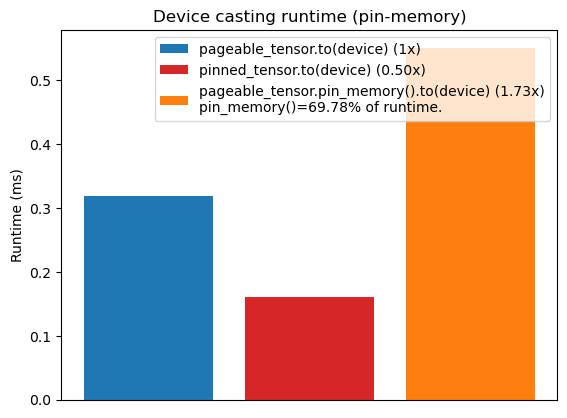

In [2]:
import torch
import gc
from torch.utils.benchmark import Timer
import matplotlib.pyplot as plt


# Función auxiliar que mide el tiempo de ejecución mediano de un comando dado como cadena de texto.
# Usa autorange adaptativo para obtener mediciones estables en entre 1 y 20 segundos.
def timer(cmd):
    median = (
        Timer(cmd, globals=globals())
        .adaptive_autorange(min_run_time=1.0, max_run_time=20.0)
        .median
        * 1000  # Convierte de segundos a milisegundos
    )
    print(f"{cmd}: {median: 4.4f} ms")
    return median

# Tensor en memoria paginable (comportamiento por defecto de PyTorch, es decir, pin_memory=False)
pageable_tensor = torch.randn(1_000_000)

# Tensor creado directamente en memoria fijada (page-locked, pin_memory=True)
# lo que evita que el SO lo mueva al disco y permite transferencias CPU→GPU más rápidas
pinned_tensor = torch.randn(1_000_000, pin_memory=True)

# Mide cuánto tarda enviar cada tipo de tensor a la GPU
pageable_to_device = timer("pageable_tensor.to('cuda:0')")    # Paginable → GPU
pinned_to_device = timer("pinned_tensor.to('cuda:0')")        # Fijado → GPU
pin_mem = timer("pageable_tensor.pin_memory()")               # Solo la operación de fijar en memoria
pin_mem_to_device = timer("pageable_tensor.pin_memory().to('cuda:0')")  # Fijar y luego enviar a GPU

# Calcula las ratios de tiempo relativas al caso base (tensor paginable)
r1 = pinned_to_device / pageable_to_device       # Cuánto más rápido es el tensor fijado
r2 = pin_mem_to_device / pageable_to_device      # Cuánto más lento es fijar y luego enviar

# Crea una gráfica de barras para comparar visualmente los tiempos de transferencia
fig, ax = plt.subplots()

xlabels = [0, 1, 2]
bar_labels = [
    "pageable_tensor.to(device) (1x)",
    f"pinned_tensor.to(device) ({r1:4.2f}x)",
    f"pageable_tensor.pin_memory().to(device) ({r2:4.2f}x)"
    f"\npin_memory()={100*pin_mem/pin_mem_to_device:.2f}% of runtime.",
]
values = [pageable_to_device, pinned_to_device, pin_mem_to_device]
colors = ["tab:blue", "tab:red", "tab:orange"]
ax.bar(xlabels, values, label=bar_labels, color=colors)

ax.set_ylabel("Runtime (ms)")
ax.set_title("Device casting runtime (pin-memory)")
ax.set_xticks([])
ax.legend()

plt.show()

# Libera los tensores de memoria y fuerza la recolección de basura para evitar fugas
del pageable_tensor, pinned_tensor
_ = gc.collect()


Podemos observar que enviar un tensor de memoria fijada a la GPU es considerablemente
más rápido que hacerlo con un tensor paginable, porque internamente un tensor paginable
debe copiarse a memoria fijada antes de ser enviado a la GPU.

Sin embargo, contrariamente a una creencia bastante extendida, llamar a
`~torch.Tensor.pin_memory()`{.interpreted-text role="meth"} sobre un
tensor paginable antes de enviarlo a la GPU no debería aportar ninguna
mejora significativa de rendimiento; al contrario, esta llamada suele ser más lenta que
ejecutar directamente la transferencia. Tiene sentido, ya que en realidad le estamos
pidiendo a Python que realice una operación que CUDA realizará de todas formas
antes de copiar los datos del host al dispositivo.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTA:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>La implementación de PyTorch de <a href="https://github.com/pytorch/pytorch/blob/5298acb5c76855bc5a99ae10016efc86b27949bd/aten/src/ATen/native/Memory.cpp#L58">pin_memory</a>, que se apoya en la creación de un almacenamiento completamente nuevo en memoria fijada mediante <a href="https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__MEMORY.html#group__CUDART__MEMORY_1gb65da58f444e7230d3322b6126bb4902">cudaHostAlloc</a>, podría ser, en casos poco frecuentes, más rápida que la transición de datos en fragmentos que realiza <code>cudaMemcpy</code>. En este caso también, la observación puede variar según el hardware disponible, el tamaño de los tensores enviados o la cantidad de RAM disponible.</p>

</div>


`non_blocking=True`
===================

Como se mencionó anteriormente, muchas operaciones de PyTorch tienen la opción de
ejecutarse de forma asíncrona respecto al host mediante el argumento `non_blocking`.

Aquí, para medir con precisión los beneficios de usar `non_blocking`, diseñaremos
un experimento algo más complejo, ya que queremos evaluar la velocidad con la que
se pueden enviar múltiples tensores a la GPU con y sin `non_blocking`.


copy_to_device_blocking(*tensors):  11.7063 ms
copy_to_device_nonblocking(*tensors):  8.0529 ms


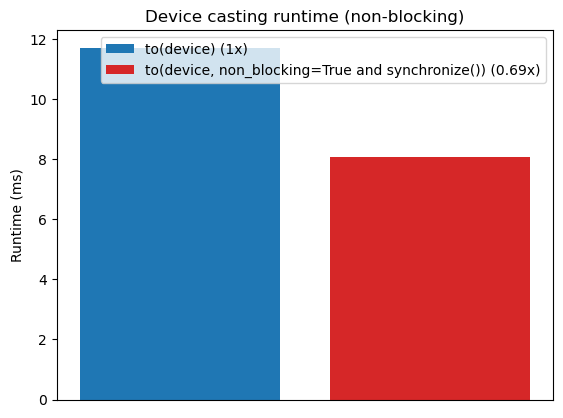

In [16]:
# Copia bloqueante: envía cada tensor a la GPU de forma secuencial.
# El hilo principal de la CPU espera a que cada copia termine de ser recogida por parte de la GPU antes de iniciar la siguiente.
def copy_to_device_blocking(*tensors):
    result = []
    for tensor in tensors:
        # .to("cuda:0") lanza la copia y bloquea la CPU hasta recibir confirmación de la GPU
        result.append(tensor.to("cuda:0"))
    return result

# Copia asíncrona (non_blocking): inicia todas las copias sin esperar a que cada una termine de ser recogida por parte de la GPU.
# Al finalizar el bucle, se hace una única sincronización para garantizar que todas han completado.
def copy_to_device_nonblocking(*tensors):
    result = []
    for tensor in tensors:
        # to(device, non_blocking=True) lanza la copia a la GPU sin que la CPU espere confirmación;
        # la GPU la ejecutará en el stream activo en cuanto pueda.
        result.append(tensor.to("cuda:0", non_blocking=True))
    # Sincronización explícita: bloquea la CPU hasta que todas las copias lanzadas
    # han completado en la GPU.
    torch.cuda.synchronize()
    return result

# Crea una lista de 1000 tensores pequeños para medir el efecto del non_blocking
tensors = [torch.randn(1000) for _ in range(1000)]
to_device_blocking = timer("copy_to_device_blocking(*tensors)")
to_device_nonblocking = timer("copy_to_device_nonblocking(*tensors)")

# Ratio: cuánto más rápida es la versión asíncrona respecto a la bloqueante
r1 = to_device_nonblocking / to_device_blocking

# Gráfica de comparación de tiempos
fig, ax = plt.subplots()

xlabels = [0, 1]
bar_labels = [f"to(device) (1x)", f"to(device, non_blocking=True and synchronize()) ({r1:4.2f}x)"]
colors = ["tab:blue", "tab:red"]
values = [to_device_blocking, to_device_nonblocking]

ax.bar(xlabels, values, label=bar_labels, color=colors)

ax.set_ylabel("Runtime (ms)")
ax.set_title("Device casting runtime (non-blocking)")
ax.set_xticks([])
ax.legend()

plt.show()


---

## Conclusión parcial

Hasta este punto hemos estudiado dos mecanismos independientes para acelerar las transferencias de tensores de CPU a GPU, y hemos medido su impacto por separado.

### 1. `pin_memory` — dónde vive el tensor en la RAM

| Tipo de memoria | Qué hace CUDA (la biblioteca) al copiar |
|---|---|
| Paginable (por defecto) | Crea internamente una copia temporal en memoria fijada → luego copia a GPU (dos pasos) |
| Fijada (`pin_memory=True`) | Copia directamente desde la RAM a la GPU vía DMA (un solo paso) |

**Conclusión clave:** alojar el tensor en memoria fijada *desde el momento de su creación* elimina ese paso de staging y hace la transferencia notablemente más rápida.

**Trampa frecuente:** llamar `tensor.pin_memory()` justo antes de `.to(device)` *no* aporta mejora; al contrario, es más lento que la transferencia directa, porque estamos pidiendo a Python que realice explícitamente lo que la biblioteca CUDA haría de todas formas internamente.

---

### 2. `non_blocking=True` — si el hilo principal espera o no

Internamente PyTorch siempre usa `cudaMemcpyAsync`. Lo que varía es si se añade una sincronización inmediata:

| Modo | Comportamiento del hilo principal de la CPU|
|---|---|
| `non_blocking=False` (por defecto) | Se llama `cudaStreamSynchronize` tras cada copia → el hilo espera |
| `non_blocking=True` | No hay sincronización por copia → el hilo lanza todas las copias y continúa |

**Conclusión clave:** cuando se copian *múltiples* tensores, `non_blocking=True` seguido de una única `torch.cuda.synchronize()` al final es más rápido que esperar a que cada copia termine antes de lanzar la siguiente.

---

### 3. Streams CUDA en GPU — solapamiento de copia y cómputo

Usando un stream secundario para la GPU (`s = torch.cuda.Stream()`) se puede hacer que la copia CPU→GPU y el cómputo en GPU se ejecuten en paralelo, en lugar de secuencialmente. Para que ese solapamiento sea posible deben cumplirse **tres condiciones simultáneas**:

1. El tensor de origen debe estar en **memoria fijada** (`pin_memory=True`).
2. La copia debe lanzarse por parte de la CPU con **`non_blocking=True`**.
3. La copia debe ejecutarse en un **stream CUDA secundario en GPU** (distinto al stream principal de la GPU donde corre el cómputo).

Si falta cualquiera de las tres condiciones, la copia en GPU y el cómputo que se esté haciendo en GPU, se ejecutan de forma consecutiva en la GPU, sin solapamiento.

---

A continuación estudiaremos qué ocurre cuando combinamos `pin_memory` y `non_blocking` juntos.


Sinergias
=========

Ahora que hemos demostrado que la transferencia de datos de tensores ya en
memoria fijada a la GPU es más rápida que desde memoria paginable, y que
sabemos que realizar estas transferencias de forma asíncrona también es más
rápido que de forma síncrona, podemos medir el rendimiento de las combinaciones
de ambos enfoques. Primero, escribamos un par de funciones nuevas que llamen a
`pin_memory` y a `to(device)` sobre cada tensor:


In [19]:
# Copia bloqueante con pin_memory previo: fija cada tensor en memoria page-locked
# y luego lo envía a la GPU de forma bloqueante. Combina dos operaciones costosas.
def pin_copy_to_device_blocking(*tensors):
    result = []
    for tensor in tensors:
        # pin_memory() copia el tensor a memoria fijada (bloquea el hilo principal)
        # .to("cuda:0") lo transfiere a la GPU de forma bloqueante
        # OJO, AQUI VARIA RESPECTO A ESTA FUNCION DEFINIDA ANTERIORMENTE: 
        # Se esta poniendo pin_memory(), lo que hace que cada tensor se fije en memoria antes de enviarlo a la GPU.
        result.append(tensor.pin_memory().to("cuda:0"))
    return result

# Copia asíncrona con pin_memory previo: fija cada tensor en memoria page-locked
# y lo envía a la GPU de forma asíncrona, con una única sincronización al final.
def pin_copy_to_device_nonblocking(*tensors):
    result = []
    for tensor in tensors:
        # pin_memory() bloquea la CPU hasta que el tensor queda fijado en memoria page-locked.
        # to(device, non_blocking=True) lanza la copia a la GPU sin que la CPU espere confirmación;
        # la GPU la ejecutará en el stream activo en cuanto pueda.
        result.append(tensor.pin_memory().to("cuda:0", non_blocking=True))
    # Sincronización explícita: bloquea la CPU hasta que todas las copias lanzadas
    # han completado en la GPU.
    torch.cuda.synchronize()
    return result

Los beneficios de usar `~torch.Tensor.pin_memory`{.interpreted-text
role="meth"} son más pronunciados con lotes de tensores de tamaño considerable:


copy_to_device_blocking(*tensors):  422.3796 ms
copy_to_device_nonblocking(*tensors):  384.7881 ms
copy_to_device_blocking(*tensors_pinned):  170.7331 ms
copy_to_device_nonblocking(*tensors_pinned):  159.9730 ms
pin_copy_to_device_blocking(*tensors):  523.7296 ms
pin_copy_to_device_nonblocking(*tensors):  340.7763 ms


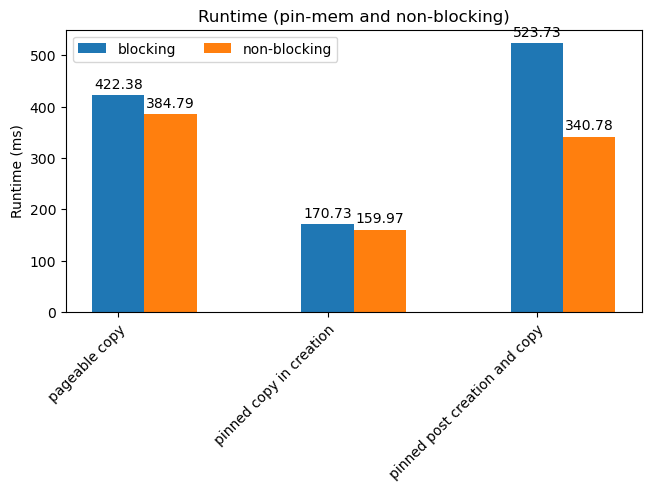

In [21]:
# Usa tensores grandes (1M elementos) para que el efecto del pin_memory sea más pronunciado
tensors = [torch.randn(1_000_000) for _ in range(1000)]
# Mide las distintas estrategias de copia con tensores paginables
page_copy = timer("copy_to_device_blocking(*tensors)")
page_copy_nb = timer("copy_to_device_nonblocking(*tensors)")

# Tensores ya creados directamente en memoria fijada (más rápidos de enviar a GPU)
tensors_pinned = [torch.randn(1_000_000, pin_memory=True) for _ in range(1000)]
# Mide las estrategias de copia con tensores ya fijados en memoria
pinned_copy = timer("copy_to_device_blocking(*tensors_pinned)")
pinned_copy_nb = timer("copy_to_device_nonblocking(*tensors_pinned)")

# Mide el coste de fijar manualmente en Python antes de copiar (suele ser más lento)
pin_and_copy = timer("pin_copy_to_device_blocking(*tensors)")
pin_and_copy_nb = timer("pin_copy_to_device_nonblocking(*tensors)")

# Construcción de la gráfica agrupada para comparar bloqueante vs asíncrono en cada estrategia
strategies = ("pageable copy", "pinned copy in creation", "pinned post creation and copy")
blocking = {
    "blocking": [page_copy, pinned_copy, pin_and_copy],
    "non-blocking": [page_copy_nb, pinned_copy_nb, pin_and_copy_nb],
}

x = torch.arange(3)
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout="constrained")

# Dibuja un grupo de barras por cada modalidad (bloqueante / no bloqueante)
for attribute, runtimes in blocking.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, runtimes, width, label=attribute)
    # Muestra el valor de tiempo encima de cada barra
    ax.bar_label(rects, padding=3, fmt="%.2f")
    multiplier += 1

ax.set_ylabel("Runtime (ms)")
ax.set_title("Runtime (pin-mem and non-blocking)")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(strategies)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.legend(loc="upper left", ncols=3)

plt.show()

# Libera los tensores y fuerza la recolección de basura
del tensors, tensors_pinned
_ = gc.collect()


## Conclusiones del benchmark (CPU → GPU)

Los tiempos exactos varían según el hardware, pero el patrón de resultados es consistente:

| Estrategia | Modo bloqueante | Modo no bloqueante | Efecto de `non_blocking` |
|---|---|---|---|
| `pageable copy` (memoria normal) | lento (referencia) | algo más rápido | mejora moderada (~10 %) |
| `pinned copy` (pre-fijado en creación) | **el más rápido** | **el más rápido** | mejora pequeña (~5 %) |
| `pin and copy` (fijar + copiar en el momento de la transferencia) | **el más lento** | mejora notable | mayor beneficio relativo (~30 %) |

### 1. La memoria pre-fijada es la estrategia más rápida

Cuando los tensores ya están alojados en **memoria fijada** (`pin_memory=True`) desde su creación, la transferencia a GPU es notablemente más rápida que desde memoria paginable (típicamente más del doble de rápida). La DMA puede acceder directamente a las páginas de memoria sin necesidad de un buffer intermedio, eliminando el paso de staging que CUDA realiza internamente con tensores paginables.

### 2. `non_blocking=True` ayuda, pero en distinta medida según la estrategia

- **`pageable copy`**: mejora modesta. La CPU lanza la copia y continúa sin esperar, pero el coste del buffer intermedio (staging interno de CUDA) sigue presente.
- **`pinned copy`**: mejora marginal. La transferencia ya es tan rápida que el solapamiento CPU-GPU aporta poco margen adicional.
- **`pin and copy`**: el mayor beneficio relativo. `pin_memory()` bloquea la CPU hasta fijar las páginas; con `non_blocking=True` esa espera se solapa parcialmente con la transferencia DMA hacia la GPU, reduciendo el tiempo total de forma apreciable.

### 3. Fijar en el momento de la copia es la peor opción en modo bloqueante

La estrategia `pin and copy` ("pinned post creation and copy") encadena `pin_memory()` + `.to("cuda:0")` secuencialmente, sumando ambos costes. En modo bloqueante es **más lento incluso que copiar desde memoria paginable**. Solo recupera terreno con `non_blocking=True`.

### 4. Combinación óptima para transferencias repetidas

Si los tensores se van a transferir varias veces (p. ej., durante el entrenamiento), la estrategia recomendada es:

```python
# Pre-alojar en memoria fijada una sola vez (p. ej., al construir el dataset):
tensor = torch.randn(..., pin_memory=True)

# Transferir en cada iteración con non_blocking:
tensor.to("cuda:0", non_blocking=True)
```

Esto minimiza el tiempo de transferencia y maximiza el solapamiento entre la CPU y la GPU, sin incurrir en el coste de `pin_memory()` en cada iteración.

Posibilidad de copias incorrectas pinned (fijadas) y asíncronas (non_blocking=True) de GPU -\> CPU sino se usa bien torch.cuda.synchronize()
================================================================================================================

Hasta ahora hemos operado bajo la suposición de que las copias asíncronas
de CPU a GPU son seguras. Esto es cierto en general porque CUDA gestiona
automáticamente la sincronización para garantizar que los datos accedidos
son válidos en el momento de la lectura. OJO: ¡¡¡siempre que el tensor esté en
memoria paginable!!!

Sin embargo, en otros casos no podemos hacer la misma suposición: cuando
un tensor reside en memoria fijada, modificar el tensor original después de
lanzar la transferencia host (CPU) → dispositivo (GPU), puede corromper los
datos recibidos en la GPU si la CPU los modifica antes de que termine la copia
a la GPU.
De forma similar, cuando la transferencia se realiza en la dirección opuesta
(de GPU a CPU), no hay garantía de que los datos leídos en el destino sean
válidos sin una sincronización explícita.

Demostremos primero esto con un tensor en memoria fijada:

In [10]:
# Retardo artificial en ciclos de GPU para que la copia asíncrona no haya terminado
# cuando se modifica el tensor original, reproduciendo así la posible corrupción de datos
DELAY = 100000000
try:
    i = -1
    for i in range(100):
        # Crea un tensor de unos en memoria fijada (page-locked)
        cpu_tensor = torch.ones(1024, 1024, pin_memory=True)
        
        # Asegura que la GPU ha terminado cualquier operación previa antes de la copia
        """ 
        Realmente este synchonize() esta mal colcado aquí, está asi a proposito para la demostración.
        Se quiere garantizar que la GPU esté en estado limpio al inicio de cada iteración del bucle (por si quedaron operaciones pendientes de la iteración anterior), no esperar a que la copia del .to() actual termine.
        
        Si se pusiera después del .to(), como debería ser normalmente, entonces:
        La copia ya habría completado antes del zero_(), eliminando la condición de carrera que el test pretende demostrar. El test dejaría de mostrar la corrupción posible y perdería su utilidad.
        """
        torch.cuda.synchronize()
        
        # Inicia la copia asíncrona CPU→GPU; el hilo principal continúa inmediatamente
        cuda_tensor = cpu_tensor.to("cuda", non_blocking=True)
        # Introduce un retardo en la GPU para que la copia no haya terminado aún
        torch.cuda._sleep(DELAY)
        # Modifica (corrompe) el tensor original en memoria fijada MIENTRAS la copia está en curso.
        # Esto puede alterar los datos que la GPU está leyendo, causando resultados incorrectos.
        cpu_tensor.zero_()
        # Comprueba que los datos en GPU son correctos; puede fallar si la corrupción ocurrió
        assert (cuda_tensor == 1).all()
    print("No test failed with non_blocking and pinned tensor")
except AssertionError:
    print(f"{i}th test failed with non_blocking and pinned tensor. Skipping remaining tests")

0th test failed with non_blocking and pinned tensor. Skipping remaining tests


Usar un tensor paginable siempre funciona correctamente, entonces:

¿Por qué los paginables son "seguros" con non_blocking=True (asincrona)?
========================================================================

Cuando la biblioteca CUDA recibe una orden de copia desde memoria paginable,
no puede hacer DMA directamente (las páginas pueden estar en disco o moverse). 
Por eso, antes de iniciar la transferencia real, se hace automáticamente una
copia interna del tensor a un buffer (RAM) del host para fijarlo (staging).
A partir de ese momento, la biblioteca CUDA lee desde esa copia, no desde el 
tensor original. Por eso modificar el original no corrompe nada.


In [ ]:
i = -1
for i in range(100):
    # Crea un tensor de unos en memoria paginable, es decir, non-pinned (comportamiento por defecto)
    cpu_tensor = torch.ones(1024, 1024)
    # Asegura que la GPU ha terminado cualquier operación previa
    torch.cuda.synchronize()
    # Inicia la copia asíncrona CPU→GPU; CUDA hace internamente una copia en memoria fijada,
    # por lo que el tensor original en memoria paginable puede modificarse sin riesgo
    cuda_tensor = cpu_tensor.to("cuda", non_blocking=True)
    # Introduce un retardo en la GPU simulando trabajo paralelo
    torch.cuda._sleep(DELAY)
    # Modifica el tensor original: con memoria paginable esto es seguro porque CUDA
    # ya hizo su propia copia interna fijada antes de iniciar la transferencia
    cpu_tensor.zero_()
    # Esta aserción siempre pasa: los datos en GPU son los originales (unos)
    assert (cuda_tensor == 1).all()
print("No test failed with non_blocking and pageable tensor")

No test failed with non_blocking and pageable tensor


Otras direcciones de copia que también pueden dar problemas (GPU -\> CPU) con asincronía (non_blocking=True).
=============================================================================================================

Ahora demostremos que la copia por parte de la biblitoeca CUDA desde GPU a CPU
también puede producir resultados incorrectos sino se realiza una sincronización
explícita con:

torch.cuda.synchronize()


In [9]:
# Crea un tensor 2D en la GPU: valores de 1 a 999999 expandidos en 100 filas.
# La media esperada es exactamente 500000.
tensor = (
    torch.arange(1, 1_000_000, dtype=torch.double, device="cuda")
    .expand(100, 999999)
    .clone()
)
# Verificación: comprueba que la media del tensor GPU es correcta antes de los tests
torch.testing.assert_close(
    tensor.mean(), torch.tensor(500_000, dtype=torch.double, device="cuda")
), tensor.mean()

# Test 1: copia GPU→CPU asíncrona SIN sincronización posterior.
# La CPU puede leer datos incompletos porque la copia podría no haber terminado.
try:
    i = -1
    for i in range(100):
        # Copia asíncrona: el hilo principal no espera a que la transferencia termine
        cpu_tensor = tensor.to("cpu", non_blocking=True)
        # Accede a cpu_tensor sin sincronizar: puede obtener basura o datos parciales
        torch.testing.assert_close(
            cpu_tensor.mean(), torch.tensor(500_000, dtype=torch.double)
        )
    print("No test failed with non_blocking")
except AssertionError:
    print(f"{i}th test failed with non_blocking. Skipping remaining tests")

# Test 2: copia GPU→CPU asíncrona CON sincronización explícita.
# Garantiza que la transferencia ha completado antes de acceder a los datos en CPU.
try:
    i = -1
    for i in range(100):
        # Copia asíncrona GPU→CPU
        cpu_tensor = tensor.to("cpu", non_blocking=True)
        # Sincronización obligatoria: asegura que la copia ha terminado antes de leer
        torch.cuda.synchronize()
        # Ahora es seguro acceder a cpu_tensor; la media debe ser 500000
        torch.testing.assert_close(
            cpu_tensor.mean(), torch.tensor(500_000, dtype=torch.double)
        )
    print("No test failed with synchronize")
except AssertionError:
    print(f"One test failed with synchronize: {i}th assertion!")


0th test failed with non_blocking. Skipping remaining tests
No test failed with synchronize


En general, las copias asíncronas a un dispositivo son seguras sin
sincronización explícita únicamente cuando el destino es un dispositivo con
CUDA y el tensor original está en memoria paginable.

En resumen, copiar datos de CPU a GPU es seguro usando `non_blocking=True`,
siempre que el usuario se asegure de ejecutar una sincronización del
dispositivo antes de acceder a los datos.

Recomendaciones prácticas
=========================

A partir de nuestras observaciones podemos extraer algunas recomendaciones:

En general, `non_blocking=True` proporcionará buen rendimiento independientemente
de si el tensor original está o no en memoria fijada. Si el tensor ya está en
memoria fijada, la transferencia puede acelerarse, pero fijarlo manualmente en
memoria fijada desde el hilo principal de Python es una operación bloqueante en el
host y, por tanto, anulará gran parte del beneficio de usar `non_blocking=True`
(ya que CUDA realizará de todas formas la transferencia de [pin\_memory]{.title-ref}
internamente).

Cabe preguntarse entonces para qué sirve el método
`~torch.Tensor.pin_memory`{.interpreted-text role="meth"}. En la siguiente
sección exploraremos cómo puede usarse para acelerar aún más la transferencia
de datos.

Consideraciones adicionales
============================

PyTorch proporciona la clase
`~torch.utils.data.DataLoader`{.interpreted-text role="class"}, cuyo
constructor acepta un argumento `pin_memory`. Teniendo en cuenta la discusión
anterior sobre `pin_memory`, puede resultar curioso cómo el `DataLoader`
consigue acelerar las transferencias si el fijado de memoria es inherentemente
bloqueante.

La clave está en que el `DataLoader` utiliza un hilo separado para gestionar
la transferencia de datos de memoria paginable a memoria fijada, evitando así
cualquier bloqueo en el hilo principal.

Para ilustrar esto, usaremos el primitivo `TensorDict` de la biblioteca homónima.
Al invocar `~tensordict.TensorDict.to`{.interpreted-text role="meth"}, el
comportamiento por defecto es enviar los tensores al dispositivo de forma
asíncrona, seguido de una única llamada a `torch.device.synchronize()` al final.

Adicionalmente, `TensorDict.to()` incluye la opción `non_blocking_pin`, que lanza
múltiples hilos para ejecutar `pin_memory()` antes de proceder con `to(device)`.
Este enfoque puede acelerar aún más las transferencias de datos, como se demuestra
en el siguiente ejemplo.


td.to('cuda:0', non_blocking=False):  452.3457 ms
td.to('cuda:0'):  412.7749 ms
td.to('cuda:0', non_blocking_pin=True, num_threads=0):  462.8825 ms
td.to('cuda:0', non_blocking_pin=True, num_threads=4):  155.8508 ms


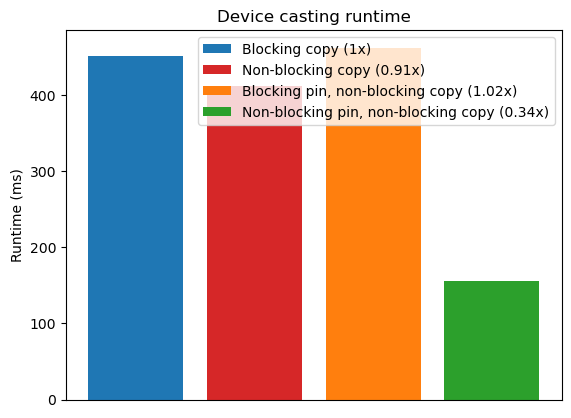

In [11]:
from tensordict import TensorDict
import torch
from torch.utils.benchmark import Timer
import matplotlib.pyplot as plt

# Crea un TensorDict con 1000 tensores de 1M elementos cada uno (dataset grande para transferir)
td = TensorDict({str(i): torch.randn(1_000_000) for i in range(1000)})

# Estrategia 1: copia bloqueante estándar (no_blocking=False)
copy_blocking = timer("td.to('cuda:0', non_blocking=False)")

# Estrategia 2: copia no bloqueante (por defecto en TensorDict); inicia todas las
# transferencias de forma asíncrona y sincroniza al final
copy_non_blocking = timer("td.to('cuda:0')")

# Estrategia 3: fija en memoria (pin_memory) en el hilo principal (bloqueante) y luego
# copia de forma no bloqueante. num_threads=0 significa un único hilo para el pinning.
copy_pin_nb = timer("td.to('cuda:0', non_blocking_pin=True, num_threads=0)")

# Estrategia 4: fija en memoria usando múltiples hilos en paralelo (num_threads=4),
# lo que acelera el pinning y permite que la copia asíncrona empiece antes
copy_pin_multithread_nb = timer("td.to('cuda:0', non_blocking_pin=True, num_threads=4)")

# Calcula las ratios respecto a la copia bloqueante base
r1 = copy_non_blocking / copy_blocking
r2 = copy_pin_nb / copy_blocking
r3 = copy_pin_multithread_nb / copy_blocking

# Gráfica comparativa de las cuatro estrategias de transferencia
fig, ax = plt.subplots()

xlabels = [0, 1, 2, 3]
bar_labels = [
    "Blocking copy (1x)",
    f"Non-blocking copy ({r1:4.2f}x)",
    f"Blocking pin, non-blocking copy ({r2:4.2f}x)",
    f"Non-blocking pin, non-blocking copy ({r3:4.2f}x)",
]
values = [copy_blocking, copy_non_blocking, copy_pin_nb, copy_pin_multithread_nb]
colors = ["tab:blue", "tab:red", "tab:orange", "tab:green"]

ax.bar(xlabels, values, label=bar_labels, color=colors)

ax.set_ylabel("Runtime (ms)")
ax.set_title("Device casting runtime")
ax.set_xticks([])
ax.legend()

plt.show()


En este ejemplo estamos transfiriendo muchos tensores grandes de CPU a GPU.
Este escenario es ideal para aprovechar `pin_memory()` con múltiples hilos,
lo que puede mejorar significativamente el rendimiento. Sin embargo, si los
tensores son pequeños, la sobrecarga del multihilo puede superar los beneficios.
Del mismo modo, si hay pocos tensores, las ventajas de fijarlos en hilos
separados son limitadas.

Como nota adicional, aunque podría parecer ventajoso crear buffers permanentes
en memoria fijada para mover tensores de memoria paginable antes de enviarlos
a la GPU, esta estrategia no acelera necesariamente el cómputo. El cuello de
botella inherente de copiar datos a memoria fijada sigue siendo un factor
limitante.

Además, transferir datos que residen en disco (ya sea en memoria compartida o
en archivos) a la GPU suele requerir un paso intermedio de copia a memoria
fijada (ubicada en RAM). Usar `non\_blocking` para transferencias de datos
grandes en este contexto puede incrementar significativamente el consumo de
RAM, con posibles efectos negativos.

En la práctica, no existe una solución universal. La eficacia de combinar
`pin_memory` con múltiples hilos y transferencias `non\_blocking` depende de
múltiples factores, entre ellos el sistema concreto, el sistema operativo, el
hardware y la naturaleza de las tareas ejecutadas. A continuación se lista
qué factores conviene revisar al intentar acelerar las transferencias entre
CPU y GPU, o al comparar el rendimiento entre distintos escenarios:

-   **Número de núcleos disponibles**

    ¿Cuántos núcleos de CPU están disponibles? ¿El sistema es compartido con
    otros usuarios o procesos que puedan competir por los recursos?

-   **Utilización de los núcleos**

    ¿Están los núcleos muy cargados por otros procesos? ¿La aplicación realiza
    otras tareas intensivas de CPU simultáneamente con las transferencias de datos?

-   **Utilización de memoria**

    ¿Cuánta memoria paginable y fijada se está usando actualmente? ¿Hay
    suficiente memoria libre para asignar más memoria fijada sin afectar al
    rendimiento del sistema? Recuerda que nada es gratuito: `pin_memory`
    consume RAM y puede impactar en otras tareas.

-   **Capacidades del dispositivo CUDA**

    ¿Admite la GPU múltiples motores DMA para transferencias de datos
    concurrentes? ¿Cuáles son las capacidades y limitaciones específicas del
    dispositivo CUDA utilizado?

-   **Número de tensores a enviar**

    ¿Cuántos tensores se transfieren en una operación típica?

-   **Tamaño de los tensores a enviar**

    ¿Cuál es el tamaño de los tensores transferidos? Unos pocos tensores
    grandes o muchos tensores pequeños pueden no beneficiarse del mismo
    enfoque de transferencia.

-   **Arquitectura del sistema**

    ¿Cómo influye la arquitectura del sistema en las velocidades de
    transferencia (por ejemplo, velocidades del bus, latencia de red)?

Además, alojar un gran número de tensores o tensores de gran tamaño en
memoria fijada puede monopolizar una porción sustancial de RAM. Esto reduce
la memoria disponible para otras operaciones críticas, como la paginación,
lo que puede afectar negativamente al rendimiento global del algoritmo.

Conclusión
==========

A lo largo de este tutorial hemos explorado varios factores críticos que
influyen en las velocidades de transferencia y en la gestión de memoria al
enviar tensores del host al dispositivo. Hemos aprendido que usar
`non_blocking=True` generalmente acelera las transferencias de datos, y que
`~torch.Tensor.pin_memory`{.interpreted-text role="meth"} también puede
mejorar el rendimiento si se implementa correctamente. Sin embargo, estas
técnicas requieren un diseño y una calibración cuidadosos para ser efectivas.

Recuerda que perfilar el código y vigilar el consumo de memoria son esenciales
para optimizar el uso de recursos y obtener el mejor rendimiento posible.

Recursos adicionales
====================

Si tienes problemas con las copias de memoria al usar dispositivos CUDA o
quieres profundizar en lo que se ha tratado en este tutorial, consulta las
siguientes referencias:

-   [CUDA toolkit memory management
    doc](https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__MEMORY.html);
-   [CUDA pin-memory
    note](https://forums.developer.nvidia.com/t/pinned-memory/268474);
-   [How to Optimize Data Transfers in CUDA
    C/C++](https://developer.nvidia.com/blog/how-optimize-data-transfers-cuda-cc/);
-   [tensordict doc](https://pytorch.org/tensordict/stable/index.html)
    y [repo](https://github.com/pytorch/tensordict).
